# Customer Churn Prediction — Logistic Regression
### Binary Classification using Logistic Regression

**Objective:** Development of a supervised binary classification model to proactively identify customers at high risk of churn, enabling targeted retention interventions before revenue loss occurs.

**Dataset:** Telecom dataset — 7,043 customers, 20 features, ~26.5% churn rate

**Pipeline Overview:**
`Load → Clean → Engineer → Split → Encode → Scale → SMOTE → L1 Select → CrossValidate → HyperParameterTune → Threshold → Evaluate`

## Step 1 — Import Libraries

All necessary libraries are imported upfront for clarity.
- **pandas / numpy** — data manipulation and numerical operations
- **matplotlib / seaborn** — visualisations
- **sklearn** — model building, evaluation, and cross-validation utilities
- **imblearn** — SMOTE for class imbalance handling
- **scipy.stats** — loguniform distribution for hyperparameter search

In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection        import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.linear_model           import LogisticRegression
from sklearn.preprocessing          import StandardScaler
from sklearn.metrics                import (classification_report, confusion_matrix,
                                             roc_auc_score, roc_curve, auc,
                                             f1_score, accuracy_score, recall_score,
                                             precision_score, precision_recall_curve)
from imblearn.over_sampling         import SMOTE
from scipy.stats                    import loguniform

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 2 — Load Dataset

The raw telecom dataset is loaded and briefly explored to understand its shape and the churn class distribution before any preprocessing.

- Each row represents one customer
- The target variable is `Churn` (Yes / No)
- Class imbalance is expected (~26% churn rate)

In [2]:
df = pd.read_csv('tele_comm.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


## Step 3 — Data Cleaning

The raw dataset requires several cleaning operations before modelling.
Key issues identified: a non-informative identifier column (`customerID`),
`TotalCharges` stored as object dtype with blank strings, and binary
categorical columns requiring numeric encoding.

**Actions performed:**
- Drop `customerID` — unique identifier with no predictive value
- Coerce `TotalCharges` to float64; impute **zero** for tenure=0 customers (new customers have no charges yet) and **median** for any remaining NaN values
- Binary encode `Churn`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, and `gender` to 1/0
- Validate: confirm zero missing values after cleaning

In [3]:
# Drop customer ID — no predictive value
df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges — stored as string in raw data, blank strings for new customers
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# New customers (tenure=0) have no charges yet — fill with 0
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0

# Safety fallback: fill any remaining NaN with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Target variable to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Binary encode Yes/No columns so feature engineering works correctly
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if df[col].dtype == object:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# Gender encoding
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

print("Missing values after cleaning:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None — dataset is clean.")
print(f"\nDataset shape after cleaning: {df.shape}")
print("\nAll dtypes OK.")

Missing values after cleaning:
None — dataset is clean.

Dataset shape after cleaning: (7043, 20)

All dtypes OK.


## Step 4 — Train / Test Split

The dataset is partitioned into training and test sets **before** any
feature engineering or transformation to prevent data leakage.
All subsequent fitting operations (scaling, SMOTE, feature selection)
are applied to training data only and then transformed onto the test set.

- **Split ratio:** 80% train / 20% test
- **Stratification:** Class distribution preserved across both splits (~26.4% churned in each)
- **Purpose of test set:** Held out entirely until final evaluation — never used during model development

In [4]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape, '| Churn rate:', round(y_train.mean(), 3))
print('Test  size:', X_test.shape,  '| Churn rate:', round(y_test.mean(), 3))

Train size: (5634, 19) | Churn rate: 0.265
Test  size: (1409, 19) | Churn rate: 0.265


## Step 5 — Feature Engineering

Domain-driven features are constructed to capture churn behavioural
patterns not directly present in the raw columns. All statistics
derived from training data only (e.g. `train_median_charge`) are passed
as parameters to the engineering function to **avoid data leakage** into the test set.

**Engineered features across 4 categories:**

| Category | Feature | Description |
|---|---|---|
| Tenure | `IsFirstYear` | Customer tenure ≤ 12 months — early-stage churn risk |
| Charges | `AvgMonthlyCharge` | TotalCharges / tenure — true monthly spend |
| Charges | `HighCostLowTenure` | High spender + new customer — highest churn signal |
| Services | `NumAdditionalServices` | Count of add-on services (security, backup, etc.) |
| Risk | `FiberOpticUser` | Fiber optic internet flag — historically higher churn |
| Risk | `IsMonthToMonth` | Month-to-month contract — no long-term commitment |
| Risk | `PaymentRisk` | Ordinal: auto payment=1 (stable), electronic check=3 (risky) |
| Lifestyle | `HasFamily` | Partner or Dependents present — lower churn tendency |

In [5]:
# Compute train statistics to apply to both sets — no leakage
train_median_charge = X_train['MonthlyCharges'].median()
train_tenure_max    = X_train['tenure'].max()

def engineer_features(df, median_charge, tenure_max):
    df = df.copy()

    # Tenure flag — early-stage customers churn more
    df['IsFirstYear'] = (df['tenure'] <= 12).astype(int)

    # Average monthly charge — true cost per month
    df['AvgMonthlyCharge'] = df.apply(
        lambda x: x['TotalCharges'] / x['tenure'] if x['tenure'] > 0 else x['MonthlyCharges'],
        axis=1)

    # Service count — more services = higher switching cost = lower churn
    add_svcs = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['NumAdditionalServices'] = df[add_svcs].apply(
        lambda x: (x == 'Yes').sum() if isinstance(x.iloc[0], str) else x.sum(), axis=1)

    # Internet type flag — fiber users show higher churn historically
    df['FiberOpticUser'] = (df['InternetService'] == 'Fiber optic').astype(int)

    # Contract type — month-to-month = no commitment = high churn risk
    df['IsMonthToMonth'] = (df['Contract'] == 'Month-to-month').astype(int)

    # Payment method risk — uses TRAIN median to avoid leakage
    df['PaymentRisk'] = df['PaymentMethod'].map({
        'Electronic check'         : 3,
        'Mailed check'             : 2,
        'Bank transfer (automatic)': 1,
        'Credit card (automatic)'  : 1})

    # High cost + low tenure = highest churn risk segment
    df['HighCostLowTenure'] = (
        (df['MonthlyCharges'] > median_charge) & (df['tenure'] < 12)
    ).astype(int)

    # Family flag — customers with dependents or partner churn less
    df['HasFamily'] = ((df['Partner'] == 1) | (df['Dependents'] == 1)).astype(int)

    return df

X_train = engineer_features(X_train, train_median_charge, train_tenure_max)
X_test  = engineer_features(X_test,  train_median_charge, train_tenure_max)  # same train stats

print('Features after engineering — Train:', X_train.shape[1])
print('New features added:', 8)

Features after engineering — Train: 27
New features added: 8


## Step 6 — Categorical Encoding

Remaining categorical columns are converted to numeric representations suitable for Logistic Regression.

- **One-hot encoding** (`pd.get_dummies`, `drop_first=True`): Applied to unordered categorical columns — avoids false ordinal relationships
- **Column alignment** (`.align(join='left')`): Ensures test set has identical feature columns as train set; missing categories filled with 0

`drop_first=True` removes one redundant dummy column per feature to prevent multicollinearity (dummy variable trap).

In [6]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)

# join='left' ensures test gets exactly the same columns as train
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print('Encoded — Train:', X_train.shape, '| Test:', X_test.shape)

Encoded — Train: (5634, 38) | Test: (1409, 38)


## Step 7 — Feature Scaling

Logistic Regression is sensitive to the scale of input features.
Without scaling, features with large numeric ranges (e.g. `TotalCharges` in hundreds)
dominate the model over features with small ranges (e.g. `tenure` 0–72).

- **Method:** StandardScaler — Z-score normalisation (mean=0, std=1)
- **Fit on train only:** Scaler learns mean and std exclusively from training data
- **Transform both:** Same learned statistics applied to test set — no leakage

In [7]:
scaler = StandardScaler()

scaler.fit(X_train)                         # fit ONLY on train
X_train_scaled = scaler.transform(X_train)  # transform train
X_test_scaled  = scaler.transform(X_test)   # apply same transform to test

print('Scaling complete. Shape:', X_train_scaled.shape)

Scaling complete. Shape: (5634, 38)


## Step 8 — Handle Class Imbalance (SMOTE)

The training set has a ~2.78:1 class imbalance (73.6% retained vs 26.4% churned).
Without correction, the model would be biased toward predicting the majority class —
achieving high accuracy while failing to identify churners.

**SMOTE (Synthetic Minority Oversampling Technique)**
Creates synthetic churn samples by interpolating between real churners
and their k-nearest neighbours in feature space:


This means synthetic churners are **realistic interpolations**, not duplicates.

- **Applied after scaling** — synthetic points created in scaled space ensuring fair distance calculations
- **Applied to training data only** — test set preserves real-world class distribution for unbiased evaluation
- **Result:** Balanced training set of equal churned and retained samples

In [9]:
smote = SMOTE(random_state=42, k_neighbors=5)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', dict(zip(*np.unique(y_train,     return_counts=True))))
print('After  SMOTE:', dict(zip(*np.unique(y_train_res, return_counts=True))))
print(f'\nTraining rows: {len(y_train)} → {len(y_train_res)} (+{len(y_train_res)-len(y_train)} synthetic churn samples)')

Before SMOTE: {0: 4139, 1: 1495}
After  SMOTE: {0: 4139, 1: 4139}

Training rows: 5634 → 8278 (+2644 synthetic churn samples)


## Step 9 — L1 Regularisation Feature Selection

With many features post-encoding, not all contribute meaningful signal.
Redundant or weak features introduce noise and increase overfitting risk.

**L1 (Lasso) Regularisation** applies a penalty that shrinks weak feature
coefficients to **exactly zero**, effectively removing them from the model.

- **Solver:** `liblinear` — the only solver supporting L1 penalty in sklearn
- **C = 0.1** — moderate regularisation; stronger penalty removes more features
- **Input:** SMOTE-balanced training data — balanced data ensures fair, unbiased feature selection
- **Same mask applied to test set** — consistent feature space maintained throughout

> Feature selection is performed **after** SMOTE so that the selector sees balanced classes and selects features that truly distinguish churn — not just majority class patterns.

In [10]:
l1_selector = LogisticRegression(
    penalty='l1', solver='liblinear', C=0.1,
    max_iter=1000, random_state=42
)
l1_selector.fit(X_train_res, y_train_res)

l1_mask           = l1_selector.coef_[0] != 0
selected_features = X_train.columns[l1_mask].tolist()

X_train_sel = X_train_res[:,  l1_mask]
X_test_sel  = X_test_scaled[:, l1_mask]

print(f'Features before L1 : {X_train_res.shape[1]}')
print(f'Features after  L1 : {X_train_sel.shape[1]}')
print(f'\nSelected features  : {selected_features}')

Features before L1 : 38
Features after  L1 : 30

Selected features  : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'TotalCharges', 'IsFirstYear', 'FiberOpticUser', 'IsMonthToMonth', 'PaymentRisk', 'HighCostLowTenure', 'HasFamily', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Two year', 'PaymentMethod_Electronic check']


## Step 10 — Cross-Validation (Baseline Evaluation)

Before hyperparameter tuning, a baseline performance estimate is established
using Stratified K-Fold cross validation. This provides a reliable,
variance-reduced performance estimate compared to a single train/validation split.

- **Strategy:** StratifiedKFold (k=5) — preserves class ratio across all folds
- **Primary metric:** Recall — minimising false negatives (missed churners) is the business priority
- **Additional metrics:** F1 Score (precision-recall balance), ROC-AUC (ranking quality)

The mean ± std across 5 folds indicates both performance level and stability.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_model = LogisticRegression(max_iter=1000, random_state=42)

cv_recall = cross_val_score(base_model, X_train_sel, y_train_res, cv=cv, scoring='recall')
cv_f1     = cross_val_score(base_model, X_train_sel, y_train_res, cv=cv, scoring='f1')
cv_auc    = cross_val_score(base_model, X_train_sel, y_train_res, cv=cv, scoring='roc_auc')

print(f'CV Recall  : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}')
print(f'CV F1      : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'CV ROC-AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

CV Recall  : 0.8111 ± 0.0111
CV F1      : 0.7808 ± 0.0047
CV ROC-AUC : 0.8516 ± 0.0021


## Step 11 — Hyperparameter Tuning (RandomizedSearchCV)

The baseline model uses default hyperparameters. Tuning identifies the
optimal configuration that maximises recall on the SMOTE-balanced training data.

**RandomizedSearchCV** samples 20 random combinations from the search space,
each evaluated via 5-fold stratified cross validation.
More efficient than exhaustive GridSearch for continuous parameter ranges.

**Search space:**
- `C` : loguniform(0.01, 10) — log-uniform sampling captures equal density across orders of magnitude
- `penalty` : L1 or L2 regularisation
- `solver` : liblinear (required for L1 support)
- `max_iter` : 500 or 1000

**Scoring metric:** Recall — aligned with the business cost of missing a churner

In [12]:
param_dist = {
    'C'        : loguniform(0.01, 10),
    'penalty'  : ['l1', 'l2'],
    'solver'   : ['liblinear'],
    'max_iter' : [500, 1000]
}

random_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions = param_dist,
    n_iter       = 20,
    cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring      = 'recall',
    n_jobs       = -1,
    random_state = 42
)

random_search.fit(X_train_sel, y_train_res)
best_model = random_search.best_estimator_

print('Best Parameters :', random_search.best_params_)
print('Best CV Recall  :', round(random_search.best_score_, 4))

# Refit on full SMOTE training data with best params
best_model.fit(X_train_sel, y_train_res)
print('\nModel refitted on full SMOTE training set.')

Best Parameters : {'C': 0.014936568554617643, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Recall  : 0.8174

Model refitted on full SMOTE training set.


## Step 12 — Decision Threshold 


In [20]:
y_prob = best_model.predict_proba(X_test_sel)[:, 1]
THRESHOLD = 0.5
y_pred = (y_prob >= THRESHOLD).astype(int)
print(f'Threshold applied : {THRESHOLD}')
print(f'Predicted churners: {y_pred.sum()} / {len(y_pred)}')


Threshold applied : 0.5
Predicted churners: 600 / 1409


## Step 13 — Final Model Evaluation

The trained model is evaluated on the **held-out test set** — data the model has
never seen during any stage of training, tuning, or selection.
This provides an unbiased estimate of real-world predictive performance.

**Metrics reported:**
- **Accuracy** — overall correct predictions (less meaningful under class imbalance)
- **Recall** — proportion of actual churners correctly identified *(primary metric)*
- **Precision** — proportion of churn predictions that were correct
- **F1 Score** — harmonic mean of precision and recall
- **ROC-AUC** — model's ability to rank churners above non-churners (threshold-independent)

**Overfitting check:** Train vs test accuracy compared — a small gap confirms the model generalises well to unseen data.

In [21]:
print('=' * 55)
print('           FINAL MODEL EVALUATION')
print('=' * 55)

acc  = accuracy_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc_ = roc_auc_score(y_test, y_prob)

print(f'\nAccuracy  : {acc:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'Precision : {prec:.4f}')
print(f'F1 Score  : {f1:.4f}')
print(f'ROC-AUC   : {auc_:.4f}')

print()
print('=' * 55)
print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print('=' * 55)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f'Confusion Matrix:')
print(f'  TP={tp}  FP={fp}')
print(f'  FN={fn}  TN={tn}')

# Overfitting check
y_train_pred = best_model.predict(X_train_sel)
print('=' * 55)
print(f'\nTrain Accuracy: {accuracy_score(y_train_res, y_train_pred):.4f}')
print(f'Test  Accuracy: {acc:.4f}')
print('\n(Small gap = no overfitting)')

           FINAL MODEL EVALUATION

Accuracy  : 0.7388
Recall    : 0.8102
Precision : 0.5050
F1 Score  : 0.6222
ROC-AUC   : 0.8389


--- Classification Report ---
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.51      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Confusion Matrix:
  TP=303  FP=297
  FN=71  TN=738

Train Accuracy: 0.7691
Test  Accuracy: 0.7388

(Small gap = no overfitting)


## Step 14 — Visualisations

Visual evaluation provides intuitive understanding of model performance:

1. **Confusion Matrix** — shows breakdown of TP, FP, FN, TN at the chosen threshold
2. **ROC-AUC Curve** — threshold-independent view of model discrimination ability; AUC closer to 1.0 is better
3. **Precision-Recall Curve** — measures the trade-off between Precision and Recall across all thresholds;
   more informative than ROC-AUC under class imbalance since it ignores True Negatives entirely and focuses
   only on how well the model identifies the minority class (churners); PR-AUC closer to 1.0 is better,
   with 0.70+ recommended for churn models; the red dot marks model performance at the chosen threshold

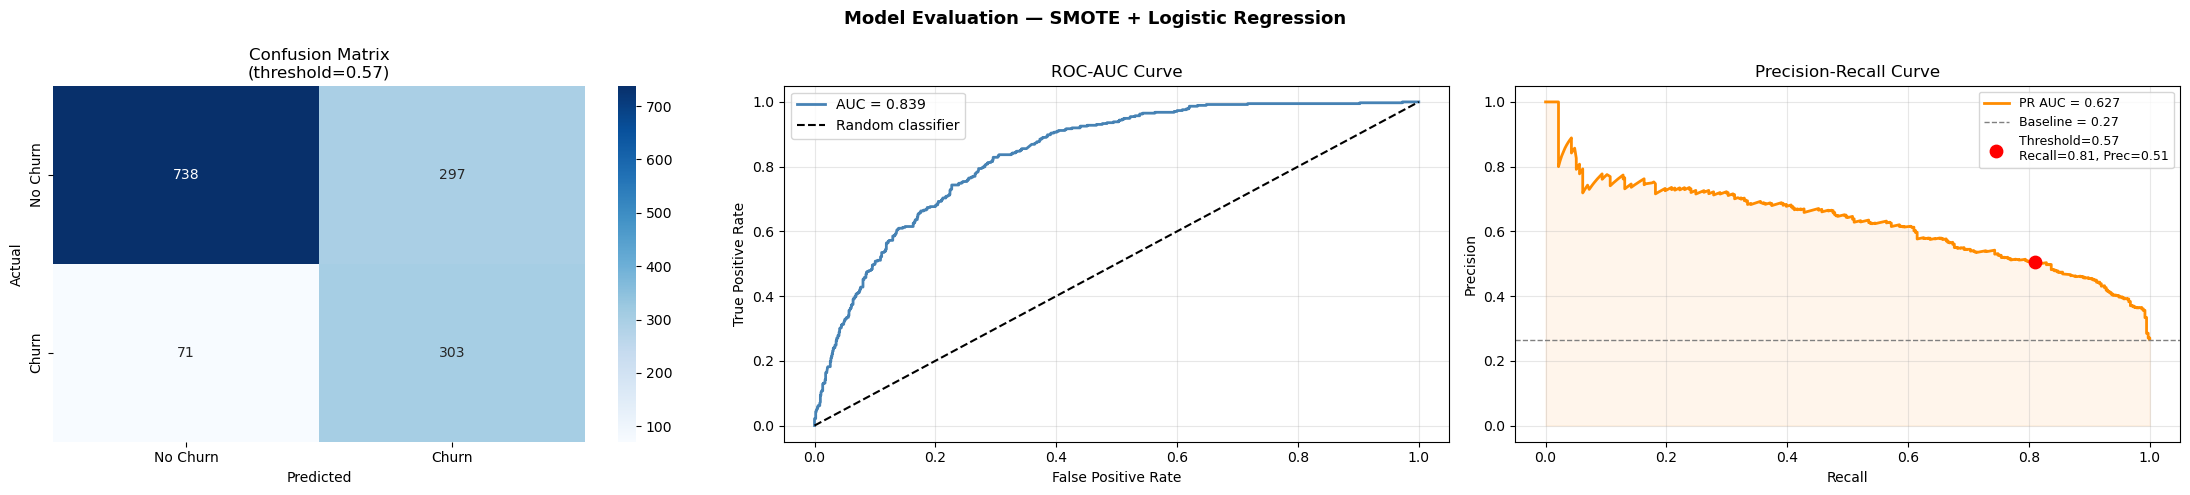

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Model Evaluation — SMOTE + Logistic Regression', fontsize=13, fontweight='bold')

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title(f'Confusion Matrix\n(threshold={OPTIMAL_THRESHOLD})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc_:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random classifier')
axes[1].set_title('ROC-AUC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve  ← NEW
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_prob)
pr_auc    = auc(recall_vals, precision_vals)
baseline  = y_test.mean()                         # random classifier baseline

axes[2].plot(recall_vals, precision_vals, color='darkorange', linewidth=2, label=f'PR AUC = {pr_auc:.3f}')
axes[2].fill_between(recall_vals, precision_vals, alpha=0.08, color='darkorange')
axes[2].axhline(baseline, color='gray', linestyle='--', linewidth=1, label=f'Baseline = {baseline:.2f}')
axes[2].scatter([rec], [prec], color='red', zorder=5, s=80,  # mark current threshold point
                label=f'Threshold={OPTIMAL_THRESHOLD}\nRecall={rec:.2f}, Prec={prec:.2f}')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()